# Gradient Descent in Neural Network

# Import Libraries

In [41]:
import random

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [43]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Make Dataset

In [44]:
X, y = make_classification(
    n_samples=1000,        # number of samples
    n_features=2,         # total number of features
    n_informative=2,       # number of informative features
    n_redundant=0,         # number of redundant features (changed from 2 to 0)
    n_repeated=0,          # no repeated features
    n_classes=2,           # binary classification
    n_clusters_per_class=2,# clusters per class
    weights=[0.5, 0.5],    # balanced classes
    class_sep=1.5,         # separation between classes
    random_state=42        # reproducibility
)

# Wrap in a DataFrame for convenience
X = pd.DataFrame(X, columns=[f"feature_{i}" for i in range(X.shape[1])])
y = pd.Series(y, name="target")

print(X.shape, y.shape)
X.head()

(1000, 2) (1000,)


,feature_0,feature_1
0,-0.499102,-0.163860
1,1.746686,1.653597
2,1.462777,1.359397
3,-3.457441,2.533645
4,1.641165,1.559449


# Plot Dataset

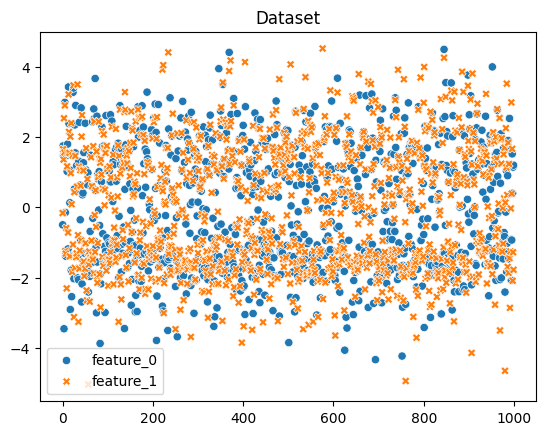

In [45]:
sns.scatterplot(data=X)
plt.title('Dataset')
plt.show()

# Train Test Split

In [46]:
X = X.values
y = y.values

In [54]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Scale Dataset

In [55]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Custom Gradient Descent

## Stochastic Gradient Descent
``` markdown
1. init weight, bias randomly
2. for i in epochs
  2.1 for row in X.row_num
    2.1.1 select a random row
    2.1.2 predict using forward propagation
    2.1.3 calculate loss
    2.1.4 update weights and biases
```

In [48]:
class CustomStochasticGD:
  def __init__(self, lr=0.01, epochs=5) -> None:
    self.lr = lr
    self.epochs = epochs
    self.weights_ = []
    self.bias_ = []
    self.loss_calculate = []
    self.epochs_loss = []
    self._init_weights = []
    self._init_bias = []


  def sigmoid(self, x)-> float:
    return 1 / (1+np.exp(-x))


  def forward_propagation(self, X, y):

    # Hidden Layer
    Z11 = self.weights_[0]*X[0] + self.weights_[2]*X[1] + self.bias_[0]
    Z12 = self.weights_[1]*X[0] + self.weights_[3]*X[1] + self.bias_[1]

    # Output Layer
    Z21 = self.weights_[4]*Z11 + self.weights_[5]*Z12 + self.bias_[2]

    return self.sigmoid(Z11), self.sigmoid(Z12), self.sigmoid(Z21)


  def update_parameters(self, X, y, y_hat, O11, O12):
    dL_dYhat_dZ = y_hat-y

    # Gradients for hidden neurons
    dO11 = self.weights_[4] * O11 * (1 - O11) * dL_dYhat_dZ
    dO12 = self.weights_[5] * O12 * (1 - O12) * dL_dYhat_dZ

    # Output layer updates
    self.weights_[4] -= self.lr * dL_dYhat_dZ * O11
    self.weights_[5] -= self.lr * dL_dYhat_dZ * O12
    self.bias_[2] -= self.lr * dL_dYhat_dZ

    # Hidden layer updates
    self.weights_[0] -= self.lr * dO11 * X[0]
    self.weights_[2] -= self.lr * dO11 * X[1]
    self.bias_[0] -= self.lr * dO11

    self.weights_[1] -= self.lr * dO12 * X[0]
    self.weights_[3] -= self.lr * dO12 * X[1]
    self.bias_[1] -= self.lr * dO12


  def fit(self, X, y):
    # self.weights_ = np.array([random.random() for _ in range(6)])
    # self.bias_ = np.array([random.random() for _ in range(3)])

    self.weights_ = np.random.uniform(-1, 1, 6)
    self.bias_ = np.random.uniform(-1, 1, 3)


    self._init_weights = self.weights_.copy()
    self._init_bias = self.bias_.copy()

    for _ in range(self.epochs):
      for _i in range(X.shape[0]):

        index = random.randint(0, X.shape[0]-1)

        O11, O12, O21 = self.forward_propagation(X[index], y[index])
        O12 = np.clip(O12, 1e-10, 1-1e-10)
        O11 = np.clip(O11, 1e-10, 1-1e-10)
        O21 = np.clip(O21, 1e-10, 1-1e-10)

        binary_loss = -y[index]*np.log(O21) - (1-y[index])*np.log(1-O21)
        self.loss_calculate.append(binary_loss)

        # Update Parameter
        self.update_parameters(X=X[index], y=y[index], y_hat=O21, O11=O11, O12=O12)

      self.epochs_loss.append(np.mean(self.loss_calculate))
      print(f'epochs {_}/{self.epochs}, loss={self.epochs_loss[_]:.4f}')

      self.loss_calculate.clear()


  def get_weights(self, type: str = 'updated'):
      # Select which set of weights to return
      if type == 'init':
          w = self._init_weights
          b = self._init_bias
      else:
          w = self.weights_
          b = self.bias_

      # Map to Keras format
      return [
          np.array([[w[0], w[1]],      # dense_4 kernel (2x2)
                    [w[2], w[3]]]),
          np.array([b[0], b[1]]),      # dense_4 bias (2,)
          np.array([[w[4]],            # dense_5 kernel (2x1)
                    [w[5]]]),
          np.array([b[2]])             # dense_5 bias (1,)
      ]

In [59]:
sgd_model = CustomStochasticGD(lr=0.01, epochs=10)
sgd_model.fit(X, y)

epochs 0/10, loss=0.6021
epochs 1/10, loss=0.2471
epochs 2/10, loss=0.2229
epochs 3/10, loss=0.1955
epochs 4/10, loss=0.1691
epochs 5/10, loss=0.1883
epochs 6/10, loss=0.1701
epochs 7/10, loss=0.1693
epochs 8/10, loss=0.1621
epochs 9/10, loss=0.2209


## Batch Gradient Descent

In [50]:
class CustomBatchGD:
    def __init__(self, lr=0.01, epochs=5) -> None:
        self.lr = lr
        self.epochs = epochs
        self.weights_ = []
        self.bias_ = []
        self.loss_calculate = []
        self.epochs_loss = []
        self._init_weights = []
        self._init_bias = []

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def sigmoid_derivative(self, x):
        return x * (1 - x)

    def fit(self, X, y):
        n_samples, n_features = X.shape

        # Initialize weights
        self.weights_ = np.random.uniform(-1, 1, 6)
        self.bias_ = np.random.uniform(-1, 1, 3)

        self._init_weights = self.weights_.copy()
        self._init_bias = self.bias_.copy()

        for epoch in range(self.epochs):
            # Forward pass (vectorized)
            Z11 = X[:, 0] * self.weights_[0] + X[:, 1] * self.weights_[2] + self.bias_[0]
            Z12 = X[:, 0] * self.weights_[1] + X[:, 1] * self.weights_[3] + self.bias_[1]
            O11 = self.sigmoid(Z11)
            O12 = self.sigmoid(Z12)
            Z21 = O11 * self.weights_[4] + O12 * self.weights_[5] + self.bias_[2]
            O21 = self.sigmoid(Z21)

            # Compute loss (binary cross-entropy)
            O21 = np.clip(O21, 1e-10, 1 - 1e-10)
            loss = -np.mean(y * np.log(O21) + (1 - y) * np.log(1 - O21))
            self.epochs_loss.append(loss)

            # Compute gradients (batch version)
            dL_dYhat = O21 - y  # derivative of BCE wrt output

            # Gradients for output layer
            dW4 = np.mean(dL_dYhat * O11)
            dW5 = np.mean(dL_dYhat * O12)
            dB2 = np.mean(dL_dYhat)

            # Hidden layer error terms
            dO11 = dL_dYhat * self.weights_[4] * self.sigmoid_derivative(O11)
            dO12 = dL_dYhat * self.weights_[5] * self.sigmoid_derivative(O12)

            # Gradients for hidden layer
            dW0 = np.mean(dO11 * X[:, 0])
            dW2 = np.mean(dO11 * X[:, 1])
            dB0 = np.mean(dO11)

            dW1 = np.mean(dO12 * X[:, 0])
            dW3 = np.mean(dO12 * X[:, 1])
            dB1 = np.mean(dO12)

            # Update weights (batch update)
            self.weights_[0] -= self.lr * dW0
            self.weights_[1] -= self.lr * dW1
            self.weights_[2] -= self.lr * dW2
            self.weights_[3] -= self.lr * dW3
            self.weights_[4] -= self.lr * dW4
            self.weights_[5] -= self.lr * dW5

            self.bias_[0] -= self.lr * dB0
            self.bias_[1] -= self.lr * dB1
            self.bias_[2] -= self.lr * dB2

            print(f"Epoch {epoch+1}/{self.epochs}, Loss={loss:.4f}")

    def predict(self, X):
        Z11 = X[:, 0] * self.weights_[0] + X[:, 1] * self.weights_[2] + self.bias_[0]
        Z12 = X[:, 0] * self.weights_[1] + X[:, 1] * self.weights_[3] + self.bias_[1]
        O11 = self.sigmoid(Z11)
        O12 = self.sigmoid(Z12)
        Z21 = O11 * self.weights_[4] + O12 * self.weights_[5] + self.bias_[2]
        O21 = self.sigmoid(Z21)
        return (O21 >= 0.5).astype(int)

    def get_weights(self, type: str = 'updated'):
        if type == 'init':
            w = self._init_weights
            b = self._init_bias
        else:
            w = self.weights_
            b = self.bias_
        return [
            np.array([[w[0], w[1]],
                      [w[2], w[3]]]),
            np.array([b[0], b[1]]),
            np.array([[w[4]],
                      [w[5]]]),
            np.array([b[2]])
        ]


In [60]:
bgd_model = CustomBatchGD(lr=0.01, epochs=10)
bgd_model.fit(X, y)

Epoch 1/10, Loss=0.7464
Epoch 2/10, Loss=0.7458
Epoch 3/10, Loss=0.7453
Epoch 4/10, Loss=0.7448
Epoch 5/10, Loss=0.7443
Epoch 6/10, Loss=0.7438
Epoch 7/10, Loss=0.7432
Epoch 8/10, Loss=0.7427
Epoch 9/10, Loss=0.7422
Epoch 10/10, Loss=0.7417


## Mini-Batch Gradient Descent

In [52]:
class CustomMiniBatchGD:
    def __init__(self, lr=0.01, epochs=10, batch_size=32) -> None:
        self.lr = lr
        self.epochs = epochs
        self.batch_size = batch_size
        self.weights_ = []
        self.bias_ = []
        self.loss_calculate = []
        self.epochs_loss = []
        self._init_weights = []
        self._init_bias = []

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def sigmoid_derivative(self, x):
        return x * (1 - x)

    def fit(self, X, y):
        n_samples, n_features = X.shape

        # Initialize weights and biases
        self.weights_ = np.random.uniform(-1, 1, 6)
        self.bias_ = np.random.uniform(-1, 1, 3)

        self._init_weights = self.weights_.copy()
        self._init_bias = self.bias_.copy()

        for epoch in range(self.epochs):
            # Shuffle data
            indices = np.arange(n_samples)
            np.random.shuffle(indices)
            X = X[indices]
            y = y[indices]

            epoch_loss = []

            # Loop over mini-batches
            for start in range(0, n_samples, self.batch_size):
                end = start + self.batch_size
                X_batch = X[start:end]
                y_batch = y[start:end]

                # === Forward Pass ===
                Z11 = X_batch[:, 0] * self.weights_[0] + X_batch[:, 1] * self.weights_[2] + self.bias_[0]
                Z12 = X_batch[:, 0] * self.weights_[1] + X_batch[:, 1] * self.weights_[3] + self.bias_[1]
                O11 = self.sigmoid(Z11)
                O12 = self.sigmoid(Z12)
                Z21 = O11 * self.weights_[4] + O12 * self.weights_[5] + self.bias_[2]
                O21 = self.sigmoid(Z21)

                # === Compute Loss ===
                O21 = np.clip(O21, 1e-10, 1 - 1e-10)
                loss = -np.mean(y_batch * np.log(O21) + (1 - y_batch) * np.log(1 - O21))
                epoch_loss.append(loss)

                # === Gradients ===
                dL_dYhat = O21 - y_batch

                # Output layer
                dW4 = np.mean(dL_dYhat * O11)
                dW5 = np.mean(dL_dYhat * O12)
                dB2 = np.mean(dL_dYhat)

                # Hidden layer
                dO11 = dL_dYhat * self.weights_[4] * self.sigmoid_derivative(O11)
                dO12 = dL_dYhat * self.weights_[5] * self.sigmoid_derivative(O12)

                dW0 = np.mean(dO11 * X_batch[:, 0])
                dW2 = np.mean(dO11 * X_batch[:, 1])
                dB0 = np.mean(dO11)

                dW1 = np.mean(dO12 * X_batch[:, 0])
                dW3 = np.mean(dO12 * X_batch[:, 1])
                dB1 = np.mean(dO12)

                # === Update Parameters ===
                self.weights_[0] -= self.lr * dW0
                self.weights_[1] -= self.lr * dW1
                self.weights_[2] -= self.lr * dW2
                self.weights_[3] -= self.lr * dW3
                self.weights_[4] -= self.lr * dW4
                self.weights_[5] -= self.lr * dW5

                self.bias_[0] -= self.lr * dB0
                self.bias_[1] -= self.lr * dB1
                self.bias_[2] -= self.lr * dB2

            # Mean loss for epoch
            mean_loss = np.mean(epoch_loss)
            self.epochs_loss.append(mean_loss)
            print(f"Epoch {epoch+1}/{self.epochs}, Loss={mean_loss:.4f}")

    def predict(self, X):
        Z11 = X[:, 0] * self.weights_[0] + X[:, 1] * self.weights_[2] + self.bias_[0]
        Z12 = X[:, 0] * self.weights_[1] + X[:, 1] * self.weights_[3] + self.bias_[1]
        O11 = self.sigmoid(Z11)
        O12 = self.sigmoid(Z12)
        Z21 = O11 * self.weights_[4] + O12 * self.weights_[5] + self.bias_[2]
        O21 = self.sigmoid(Z21)
        return (O21 >= 0.5).astype(int)

    def get_weights(self, type: str = 'updated'):
        if type == 'init':
            w = self._init_weights
            b = self._init_bias
        else:
            w = self.weights_
            b = self.bias_
        return [
            np.array([[w[0], w[1]],
                      [w[2], w[3]]]),
            np.array([b[0], b[1]]),
            np.array([[w[4]],
                      [w[5]]]),
            np.array([b[2]])
        ]

In [61]:
mbgd_model = CustomMiniBatchGD(lr=0.01, epochs=10, batch_size=32)
mbgd_model.fit(X, y)

Epoch 1/10, Loss=0.6648
Epoch 2/10, Loss=0.6502
Epoch 3/10, Loss=0.6298
Epoch 4/10, Loss=0.6160
Epoch 5/10, Loss=0.6029
Epoch 6/10, Loss=0.5935
Epoch 7/10, Loss=0.5801
Epoch 8/10, Loss=0.5721
Epoch 9/10, Loss=0.5640
Epoch 10/10, Loss=0.5528


# Parameter Compare

In [62]:
sgd_model.get_weights()

[array([[-0.31391103, -0.78085013],
        [-1.74937317, -0.06649797]]),
 array([ 0.34465253, -0.35649759]),
 array([[-1.41457622],
        [ 0.55557738]]),
 array([1.08811661])]

In [63]:
bgd_model.get_weights()

[array([[ 0.6118054 ,  0.34901736],
        [-0.03515073,  0.27031775]]),
 array([0.47490506, 0.96575289]),
 array([[0.49937471],
        [0.29103651]]),
 array([0.1736383])]

In [64]:
mbgd_model.get_weights()

[array([[-0.42476795, -0.31380715],
        [ 0.89527723, -0.71680568]]),
 array([-0.69198631,  0.82396772]),
 array([[ 0.61250261],
        [-0.990324  ]]),
 array([0.22960779])]